FILTRAGGIO

In [1]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import hashlib
import pandas as pd
from datetime import datetime, timedelta, timezone
from pathlib import Path
import librosa
import soundfile as sf
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
INPUT_AUDIO_DIR = Path("AudioSamples")
#PREPROCESSED_AUDIO_DIR = Path("AudioSamplesPreprocessed")
#PREPROCESSED_AUDIO_DIR.mkdir(parents=True, exist_ok=True)
SELECTED_AUDIO_DIR = Path("AudioSamplesFiltered")
SELECTED_AUDIO_DIR.mkdir(parents=True, exist_ok=True)
CSV_OUTPUT_PATH = "audio_samples_metadata.csv"
NOISE_PATH = "noise.wav"
#OLD_DATE_FORMAT = "%Y/%m/%d,%H:%M:%S"
DATE_FORMAT = "%Y-%m-%dT%H:%M:%S%z"
START_DATE = "2026-03-09T00:00:00+0100"
END_DATE = "2026-03-18T00:00:00+0100"

In [3]:
METADATA_KEYS = ["tmst", "noId", "blvl", "rmsv"]

def getMetadata(wav_bytes):
    metadata = {}
    i = 12  # salta RIFF + size + WAVE

    size = len(wav_bytes)

    while i + 8 <= size:
        chunk_id = wav_bytes[i:i+4]
        chunk_size = int.from_bytes(wav_bytes[i+4:i+8], "little")
        chunk_data_start = i + 8
        chunk_data_end = chunk_data_start + chunk_size

        if chunk_id == b"LIST" and wav_bytes[chunk_data_start:chunk_data_start+4] == b"INFO":
            j = chunk_data_start + 4  # salta "INFO"

            while j + 8 <= chunk_data_end:
                key = wav_bytes[j:j+4].decode("ascii", errors="ignore").strip()
                length = int.from_bytes(wav_bytes[j+4:j+8], "little")
                value_bytes = wav_bytes[j+8:j+8+length]

                # rimuove \x00 finali
                value = value_bytes.rstrip(b"\x00").decode("ascii", errors="ignore")
                if key in METADATA_KEYS:
                    metadata[key] = value
                else:
                    raise Exception(f"Unexpected metadata key: {key}")
                j += 8 + length

        # chunk allineati a 2 byte
        i = chunk_data_end + (chunk_size % 2)

    

    return metadata

In [4]:
# 1. Configurazione Parametri

audio_samples_source_directory = Path(INPUT_AUDIO_DIR)

# Conversione delle stringhe di input in oggetti datetime per il confronto
inizio = datetime.strptime(START_DATE, DATE_FORMAT)
fine = datetime.strptime(END_DATE, DATE_FORMAT)

# 2. Scansione e Filtrazione
audio_samples = []

if audio_samples_source_directory.exists():
    for input_path in audio_samples_source_directory.glob("*.wav"):
        try:
            with open(input_path, "rb") as f:
                audio_content = f.read()
                metadata = getMetadata(audio_content)
                timestamp = metadata.get("tmst")
                
                if timestamp:
                    dt = datetime.strptime(timestamp, DATE_FORMAT)
                    
                    # Filtro temporale
                    if inizio <= dt <= fine:
                        sha256_hash = hashlib.sha256(audio_content).hexdigest()
                        safe_date_string = timestamp.replace(":", "-")[:-5] # rimuove i secondi e la parte timezone per il nome del file
                        audio_samples.append({
                            "original_filename": input_path.name,
                            "filename": f"audio_{safe_date_string}.wav",
                            "sha256_hash": sha256_hash,
                            "timestamp": dt,
                            "rms energy": float(metadata.get("rmsv")),
                            })
                        
        except Exception as e:
            print(f"Errore nell'elaborazione di {input_path.name}: {e}")
else:
    print(f"Errore: La cartella '{audio_samples_source_directory}' non esiste.")

# 3. Creazione del DataFrame
audiofiles_df = pd.DataFrame(audio_samples, columns=["original_filename", "filename", "sha256_hash", "timestamp", "rms energy"])

if not audiofiles_df.empty:
    print(f"Trovati {len(audiofiles_df)} file nell'intervallo selezionato.")
    audiofiles_df = audiofiles_df.sort_values(by="timestamp", ascending=True)
    audiofiles_df = audiofiles_df.reset_index(drop=True)
else:
    print("Nessun file trovato nell'intervallo specificato.")

audiofiles_df.head()

Trovati 1389 file nell'intervallo selezionato.


,original_filename,filename,sha256_hash,timestamp,rms energy
0,audio_548329df66f2be5cebe3a3ab8688da8658eefb65...,audio_2026-03-09T16-34-22.wav,f7e49cca98eb66bc84c575410501bb551ca94f32474a53...,2026-03-09 16:34:22+01:00,222706540.0
1,audio_4308ece211efbbe098f438474dffb8efb1517af2...,audio_2026-03-09T16-39-28.wav,a7203b191c3f9af7be8209d90c837af797fcdca26a9f71...,2026-03-09 16:39:28+01:00,223201872.0
2,audio_be49fb71e4c2a540ba07d72d6d59d423ad4e15bd...,audio_2026-03-09T16-41-41.wav,1af869f1bf45aac9261cfdff10bb065641a0f9ac6b1f8c...,2026-03-09 16:41:41+01:00,223152432.0
3,audio_bf2de73f90b6f7dd200b4a58d1e8ac2f7186900a...,audio_2026-03-09T16-46-47.wav,b8d5d460127f7a9c6524a17d0e1db5932cf541059d3835...,2026-03-09 16:46:47+01:00,222891792.0
4,audio_5919f6a394c4aa055ae46794683e94673cee6288...,audio_2026-03-09T16-51-54.wav,fe2f69beded0035b305f7175e4fea671ce99388958cd98...,2026-03-09 16:51:54+01:00,222754672.0


In [5]:
# Trova tutte le occorrenze dei timestamp duplicati
# keep=False assicura di vedere TUTTI i file coinvolti nel duplicato, non solo il secondo
duplicati = audiofiles_df[audiofiles_df.duplicated(subset=['timestamp'], keep=False)]

# Ordiniamo per timestamp per vederli vicini
duplicati_ordinati = duplicati.sort_values(by='timestamp')

if not duplicati_ordinati.empty:
    print(f"Attenzione: Trovati {len(duplicati_ordinati)} file con timestamp identici.")
    display(duplicati_ordinati)
else:
    print("Ottimo! Non ci sono file con timestamp duplicati.")
    

Ottimo! Non ci sono file con timestamp duplicati.


In [6]:
audiofiles_df.to_csv(CSV_OUTPUT_PATH, index=False)

# Iteriamo sul DataFrame
for row in audiofiles_df.itertuples():
    # Sorgente: nome originale nella cartella input
    file_src = INPUT_AUDIO_DIR / row.original_filename
    
    # Destinazione: nuovo nome (già pronto nel DF) nella cartella output
    file_dst = SELECTED_AUDIO_DIR / row.filename
    
    if file_src.exists():
        shutil.copy2(file_src, file_dst)
    else:
        print(f"File '{row.original_filename}' non trovato in {INPUT_AUDIO_DIR}")

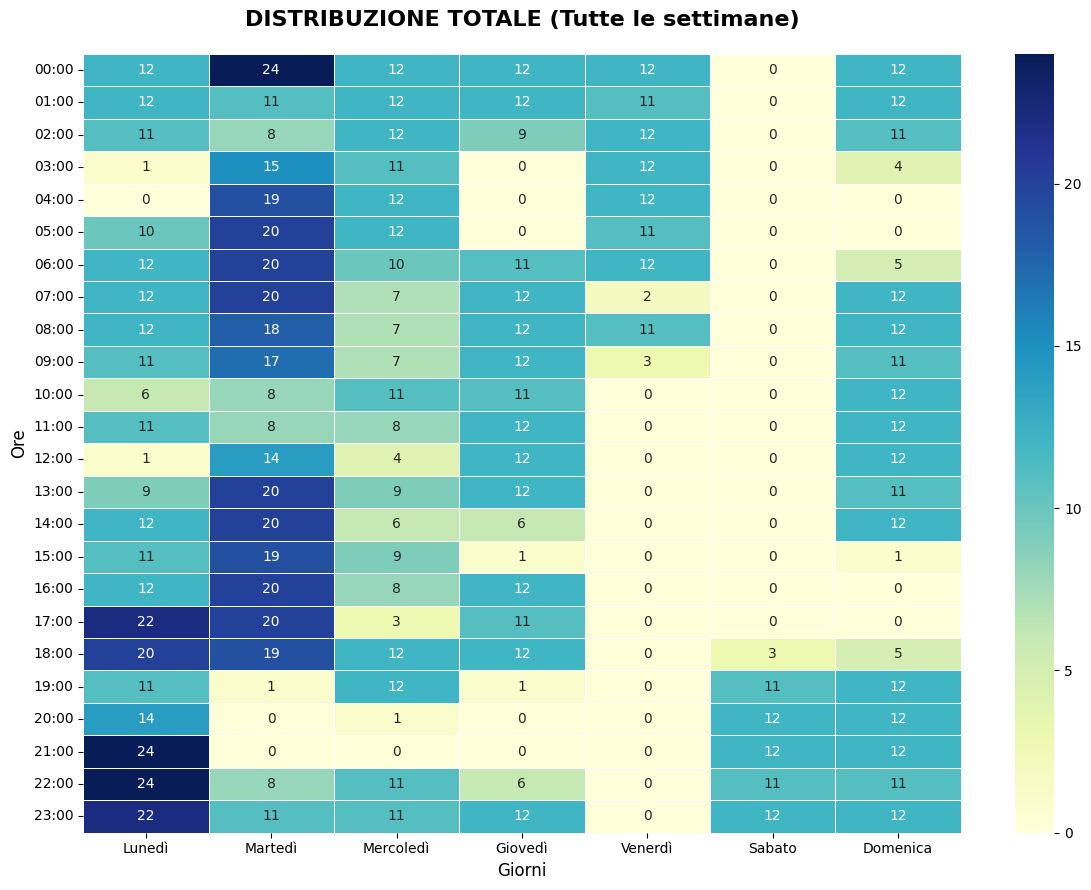

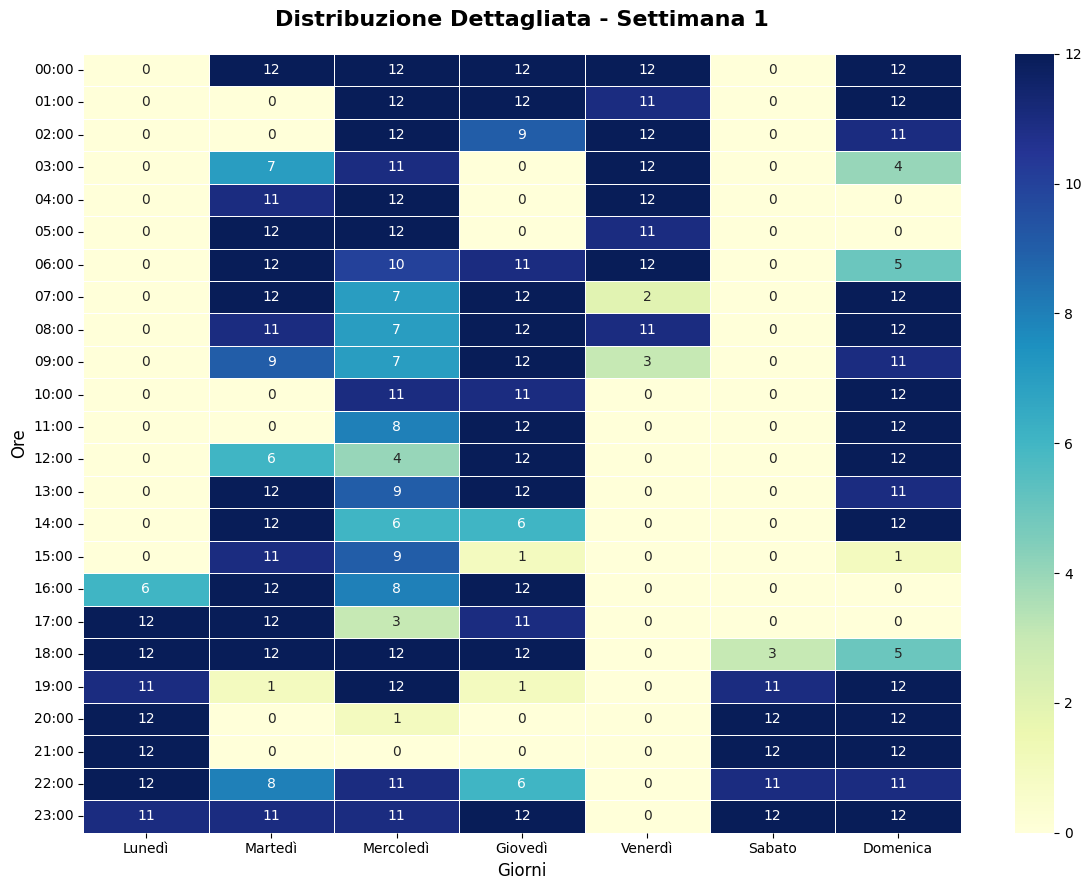

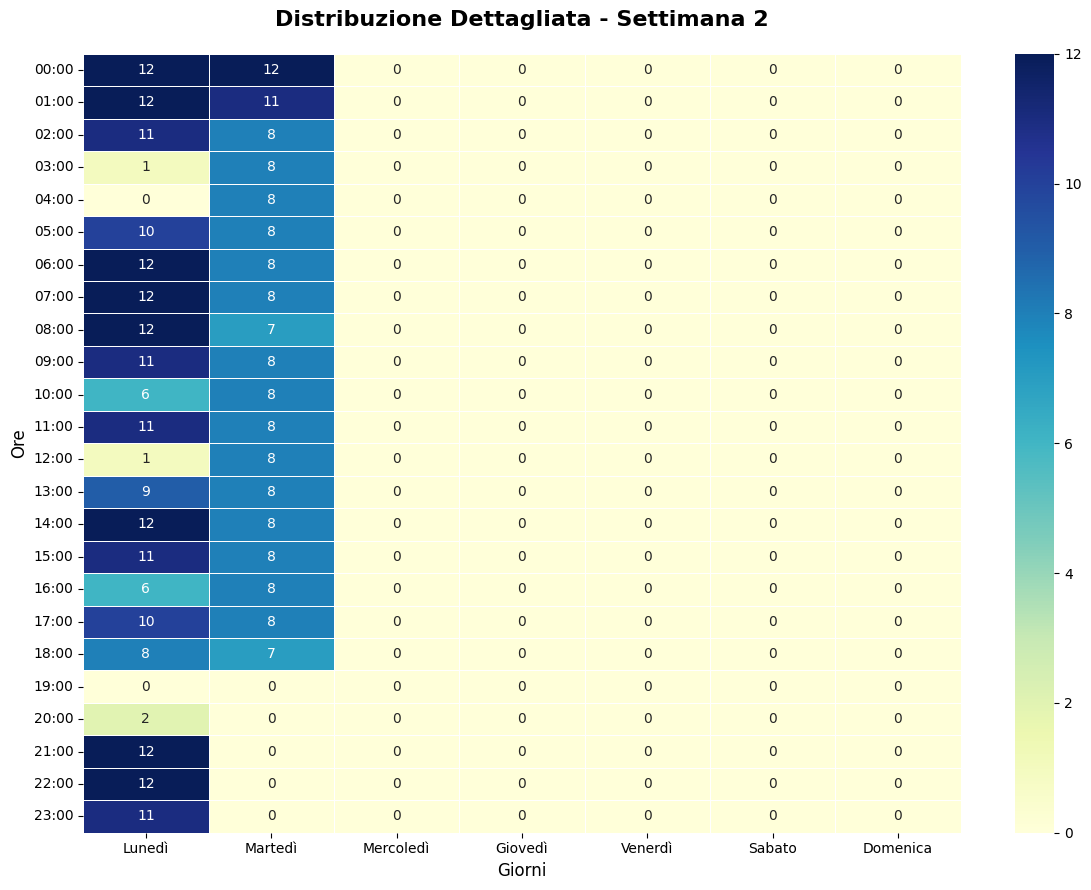

In [7]:
def plot_registration_scheduling(audio_df):
    # 1. Preparazione dati
    df = audio_df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)
    
    # 2. Creazione etichette in Italiano
    traduzione_giorni = {
        'Monday': 'Lunedì', 'Tuesday': 'Martedì', 'Wednesday': 'Mercoledì',
        'Thursday': 'Giovedì', 'Friday': 'Venerdì', 'Saturday': 'Sabato', 'Sunday': 'Domenica'
    }
    
    # Rinominiamo direttamente qui per coerenza con la Pivot
    df['Giorni'] = df['timestamp'].dt.day_name().map(traduzione_giorni)
    df['Ore'] = df['timestamp'].dt.hour.astype(str).str.zfill(2) + ":00"
    
    # Calcolo Settimana
    start_date = df['timestamp'].min() - pd.to_timedelta(df['timestamp'].min().dayofweek, unit='D')
    start_date = start_date.replace(hour=0, minute=0, second=0, microsecond=0)
    df['week_num'] = ((df['timestamp'] - start_date).dt.days // 7) + 1
    df['week_label'] = "Settimana " + df['week_num'].astype(str)
    
    # Ordinamento assi
    giorni_it = ['Lunedì', 'Martedì', 'Mercoledì', 'Giovedì', 'Venerdì', 'Sabato', 'Domenica']
    ore_ordinate = [f"{str(i).zfill(2)}:00" for i in range(24)]

    # --- FUNZIONE INTERNA PER IL PLOT (per evitare ripetizioni) ---
    def draw_heatmap(data_pivot, titolo):
        plt.figure(figsize=(12, 9))
        sns.heatmap(data_pivot, annot=True, fmt='g', cmap="YlGnBu", cbar=True, linewidths=.5)
        plt.title(titolo, fontsize=16, weight='bold', pad=20)
        plt.xlabel('Giorni', fontsize=12) # Etichetta asse X
        plt.ylabel('Ore', fontsize=12)    # Etichetta asse Y
        plt.tight_layout()
        plt.show()

    # --- PARTE 1: HEATMAP UNIFICATA ---
    pivot_all = df.pivot_table(index='Ore', columns='Giorni', 
                               values='filename', aggfunc='count')
    pivot_all = pivot_all.reindex(index=ore_ordinate, columns=giorni_it).fillna(0)
    
    draw_heatmap(pivot_all, 'DISTRIBUZIONE TOTALE (Tutte le settimane)')

    # --- PARTE 2: HEATMAP PER OGNI SETTIMANA ---
    settimane_presenti = sorted(df['week_label'].unique(), key=lambda x: int(x.split()[1]))
    
    for settimana in settimane_presenti:
        df_settimana = df[df['week_label'] == settimana]
        pivot_sett = df_settimana.pivot_table(index='Ore', columns='Giorni', 
                                             values='filename', aggfunc='count')
        pivot_sett = pivot_sett.reindex(index=ore_ordinate, columns=giorni_it).fillna(0)
        
        draw_heatmap(pivot_sett, f'Distribuzione Dettagliata - {settimana}')


plot_registration_scheduling(audiofiles_df)